In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
# try:
#     from cellacdc import cca_functions
#     from cellacdc import myutils
# except FileNotFoundError:
#     # Check if user has developer version --> add the Cell_ACDC/cellacdc
#     # folder to path and import from thre
#     sys.path.insert(0, '../cellacdc/')
#     from cellacdc import cca_functions
#     from cellacdc import myutils

# ***Import csv file generated at the end of script5 in dataprep*** 

In [2]:

overall_df = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


C:\Users\timon\AppData\Local\Temp\ipykernel_44324\1937159325.py:1: DtypeWarning: Columns (31,32,53,321,323,324,325,329) have mixed types. Specify dtype option on import or set low_memory=False.
  overall_df = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


# ***Fig 6A: plotting Whi5-mCitrine and HTB2-mScarlet curves for one example cell cycle: 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_1'*** 

In [3]:
l = display(overall_df[(overall_df['strain_sa'] == 'YCY024_1_WTlabelled') 
                            & (overall_df['growthmedium_sa'] == "SCD")
                            & (overall_df['cycle_saw_switch_sa'] == False)
                            & (overall_df['complete_cycle_sa'] == True)
                            & (overall_df['relationship_sa'] != "bud")].f_pos_cell_id_sa.unique())

array(['YCY024_1_WTlabelled_Position_1_Cell_1_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_1_Cell_2_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_2_Cell_1_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_2_Cell_3_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_6_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_7_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_8_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_9_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_9_Gen_4_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_10_Gen_3_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_10_Gen_4_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_12_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_3_Cell_13_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_4_Cell_1_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position_4_Cell_2_Gen_1_Rep_1',
       'YCY024_1_WTlabelled_Position

C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3723889817.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  a = sns.lineplot(x = "time_rel_to_bud_emergence_mins",
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3723889817.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.4, 1),  loc='upper left')
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3723889817.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15)
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3723889817.py:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  a = sns.lineplot(x = "time_rel_to_bud_emergence_mins",
C:\Users\timon\AppData\Local\Temp\ipykernel_443

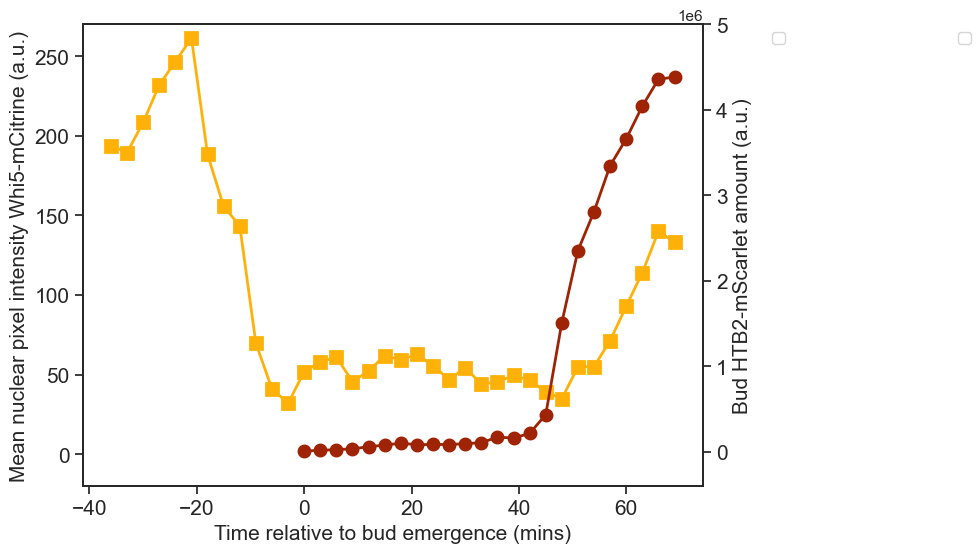

In [4]:
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'grid.color': 'lightgrey'})

plot_df = overall_df[overall_df['f_pos_cell_id_sa'] == 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_1']


palette ={"preStart": "silver", "postStart": "mediumturquoise", "preMitotic": "mediumvioletred", "mitotic": "royalblue",
          "postMitotic": "#856798", "G1": "#88b378"}

a, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                marker = 's',
                markersize=8,
                data =plot_df,
                palette = palette,
                markeredgecolor = '#feb209',
                markeredgewidth= 2,
                linewidth=2,
                dashes = False,
                color = '#feb209',
                #s=100,
                #edgecolor = 'w',
                #height=8, 
                #aspect=1.5
                )

plt.legend(bbox_to_anchor=(1.4, 1),  loc='upper left')

sns.set_style("ticks", {'grid.color': 'darkgrey', 'grid.linestyle': '--'})
#create second x-axis on right side
ax2 = plt.twinx()
ax.set_ylim(-20,270)
ax.set_ylabel("Mean nuclear pixel intensity Whi5-mCitrine (a.u.)", fontsize = 15)

ax.set_xlabel("Time relative to bud emergence (mins)", fontsize = 15)
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15)
ax2.set_ylabel("Bud HTB2-mScarlet amount (a.u.)", fontsize = 15)
ax2.set_ylim(-400000,5000000)

#plot histone cellular amount

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel",
                data =plot_df,
                marker = 'o',
                dashes = False,
                markersize=8,
                #marker="x",
                #s = 100,
                markeredgecolor = '#9f2305',
                markeredgewidth= 2,
                linewidth=2,
                color = '#9f2305',
                palette = palette,
                #height=8, 
                #aspect=1.5,
                ax=ax2)

plt.legend(bbox_to_anchor=(1.1, 1),  loc='upper left')

ax.tick_params(axis='y', which='major', labelsize=15)
ax2.tick_params(axis='y', which='major', labelsize=15)

#plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel1.svg", bbox_inches = 'tight')
plt.show()


# ***Fig 6C: dataprep***

In [5]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()
display(len(ids_first_S_daughters))
ids_that_could_not_be_manually_annotated = ["YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1",
"YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1",
"YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1",
"YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2",
"YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2",
"YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2"]

108

In [6]:
# unique frame for each cell 
test_df = overall_df[(overall_df['f_pos_cell_id_sa'].isin(ids_first_S_daughters))] 
test_df = test_df[~test_df['f_pos_cell_id_sa'].isin(ids_that_could_not_be_manually_annotated)]
unique_f_pos_cell_id = []
for fposid in ((test_df['f_pos_cell_id_sa']).unique()):
    fposid_df = test_df[test_df['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)


plotting_df['preStart_G1_duration_mins'] = plotting_df['preStart_G1_duration_frames_manual']*3
plotting_df['postStart_G1_duration_mins'] = plotting_df['postStart_G1_duration_frames_manual']*3



# ***Fig 6C: plotting***


preStart G1 duration (min)
Group: '['strain_sa']'  |  Value: 'preStart_G1_duration_mins'


C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3436310043.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plotting_df,
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3436310043.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(xtick_labels, fontsize=15)
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3436310043.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plotting_df,
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\3436310043.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLo

,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(YCY037_1_Bck2del_labelled,)",11,314.5,291.0,0.53,0,Shapiro-Wilk,0.633628,True
1,"(YCY024_1_WTlabelled,)",38,210.8,204.0,0.06,0,Shapiro-Wilk,0.818207,True
2,"(YCY038_1_Whi5Bck2doubledel_labelled,)",23,327.7,255.0,0.40,0,Shapiro-Wilk,0.021072,False
3,"(YCY030_2_Whi5del_labelled,)",27,176.9,132.0,0.86,1,Shapiro-Wilk,0.012557,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('YCY024_1_WTlabelled',) vs ('YCY030_2_Whi5del_labelled',)",38,27,0.2721,0.2451,0.0961,False,False,False,False
1,"('YCY024_1_WTlabelled',) vs ('YCY037_1_Bck2del_labelled',)",38,11,0.1442,0.0253,0.1956,False,True,False,True
2,"('YCY024_1_WTlabelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",38,23,0.0121,0.0029,0.0587,True,True,False,True
3,"('YCY030_2_Whi5del_labelled',) vs ('YCY037_1_Bck2del_labelled',)",27,11,0.0676,0.0219,0.0619,False,True,False,True
4,"('YCY030_2_Whi5del_labelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",27,23,0.0034,0.0023,0.0037,True,True,True,False
5,"('YCY037_1_Bck2del_labelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",11,23,0.8639,0.8587,0.8252,False,False,False,False



postStart G1 duration (min)
Group: '['strain_sa']'  |  Value: 'postStart_G1_duration_mins'


,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(YCY037_1_Bck2del_labelled,)",11,30.3,21.0,1.13,1,Shapiro-Wilk,0.006228,False
1,"(YCY024_1_WTlabelled,)",38,37.5,31.5,1.12,3,Shapiro-Wilk,0.000427,False
2,"(YCY038_1_Whi5Bck2doubledel_labelled,)",23,56.2,48.0,1.81,1,Shapiro-Wilk,0.000590,False
3,"(YCY030_2_Whi5del_labelled,)",27,53.6,51.0,0.38,0,Shapiro-Wilk,0.394247,True


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('YCY024_1_WTlabelled',) vs ('YCY030_2_Whi5del_labelled',)",38,27,0.0046,0.0038,0.0031,True,True,True,False
1,"('YCY024_1_WTlabelled',) vs ('YCY037_1_Bck2del_labelled',)",38,11,0.3116,0.3033,0.1152,False,False,False,False
2,"('YCY024_1_WTlabelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",38,23,0.0663,0.0279,0.1501,False,True,False,True
3,"('YCY030_2_Whi5del_labelled',) vs ('YCY037_1_Bck2del_labelled',)",27,11,0.0053,0.0051,0.0035,True,True,True,False
4,"('YCY030_2_Whi5del_labelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",27,23,0.7955,0.7850,0.5522,False,False,False,False
5,"('YCY037_1_Bck2del_labelled',) vs ('YCY038_1_Whi5Bck2doubledel_labelled',)",11,23,0.0252,0.0744,0.0351,True,False,True,True


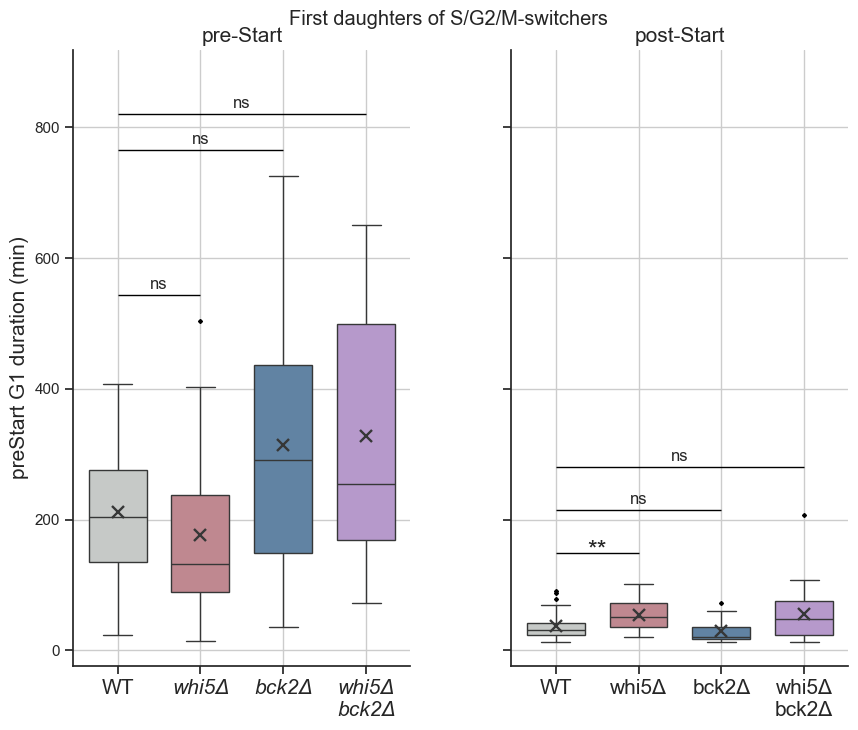

In [7]:

import importlib
import sys
sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
import core
importlib.reload(core)
from core import annotate_mwu_vs_ref, annotate_significance_vs_ref

sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"},
            'flierprops':{'marker':'D', 'markerfacecolor':'black', 'markeredgecolor':'black', 'markersize': 2}

}

strain_order_6c = [
    'YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled',
    'YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'
]
lut = {"YCY024_1_WTlabelled":"#c5c9c7", "YCY030_2_Whi5del_labelled": "#c87f89",
       "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}

xtick_labels = ["WT", "whi5Δ", "bck2Δ", "whi5Δ\nbck2Δ"]

d, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, figsize=(10, 8), sharey=True)

sns.boxplot(data=plotting_df,
            x="strain_sa", y="preStart_G1_duration_mins",
            order=strain_order_6c, showmeans=True, ax=ax3, width=0.7,
            palette=lut,
            meanprops={"marker":"x", "markerfacecolor":None,
                       "markeredgecolor":"#363737", "markersize":"8", "markeredgewidth": 1.7},
            **PROPS)
ax3.set_xticklabels(xtick_labels, fontsize=15)
for i, tick in enumerate(ax3.get_xticklabels()):
    if i > 0:
        tick.set_fontstyle("italic")
# ax3.set_yticklabels(ax3.get_yticklabels(), fontsize=15)
ax3.grid()
sns.despine(ax=ax3)
ax3.set_title("pre-Start", fontsize=15)
ax3.set_xlabel("", fontsize=15)
ax3.set_ylabel("preStart G1 duration (min)", fontsize=15)

sns.boxplot(data=plotting_df,
            x="strain_sa", y="postStart_G1_duration_mins",
            order=strain_order_6c, showmeans=True, ax=ax4, width=0.7,
            palette=lut,
            meanprops={"marker":"x", "markerfacecolor":None,
                       "markeredgecolor":"#363737", "markersize":"8", "markeredgewidth": 1.7},
            **PROPS)
ax4.set_xticklabels(xtick_labels, fontsize=15)
# for i, tick in enumerate(ax4.get_xticklabels()):
#     if i > 0:
#         tick.set_fontstyle("italic")
ax4.grid()
sns.despine(ax=ax4)
ax4.set_title("post-Start", fontsize=15)
ax4.set_xlabel("", fontsize=15)
ax4.set_ylabel("post-Start G1 duration (min)", fontsize=15)

plt.suptitle("First daughters of S/G2/M-switchers", y=0.93)
plt.subplots_adjust(wspace=0.3)

annotate_significance_vs_ref(ax3, plotting_df, x_col="strain_sa",
                    y_col="preStart_G1_duration_mins",
                    x_order=strain_order_6c,
                    ref_group="YCY024_1_WTlabelled",
                    text_gap=0.005, star_gap=-0.015,
                    show_n=False,
                    test="mwu")
annotate_significance_vs_ref(ax4, plotting_df, x_col="strain_sa",
                    y_col="postStart_G1_duration_mins",
                    x_order=strain_order_6c,
                    ref_group="YCY024_1_WTlabelled",
                    text_gap=0.005, star_gap=-0.015,
                    show_n=False,
                    test="mwu")

core.run_stats(
    plotting_df,
    value_cols="preStart_G1_duration_mins",
    group_col="strain_sa",
    title="preStart G1 duration (min)"
    )
core.run_stats(
    plotting_df,
    value_cols="postStart_G1_duration_mins",
    group_col="strain_sa",
    title="postStart G1 duration (min)"
    )

plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\Fig6_panel2.svg", bbox_inches = 'tight')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel2.svg", bbox_inches = 'tight')
# save figure 


In [8]:
import importlib
import sys

sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
import core
importlib.reload(core)
from core import run_stats

# Columns from Fig 6C plot
value_cols = ["preStart_G1_duration_mins", "postStart_G1_duration_mins"]

# WT vs mutant comparisons in plotting order
comparisons = [
    ("YCY024_1_WTlabelled", "YCY030_2_Whi5del_labelled"),
    ("YCY024_1_WTlabelled", "YCY037_1_Bck2del_labelled"),
    ("YCY024_1_WTlabelled", "YCY038_1_Whi5Bck2doubledel_labelled"),
]

strain_labels_fig6c = {
    "YCY024_1_WTlabelled": "WT",
    "YCY030_2_Whi5del_labelled": "whi5Δ",
    "YCY037_1_Bck2del_labelled": "bck2Δ",
    "YCY038_1_Whi5Bck2doubledel_labelled": "whi5Δ bck2Δ",
}

run_stats(
    plotting_df,
    value_cols,
    comparisons=comparisons,
    group_col="strain_sa",
    group_labels=strain_labels_fig6c,
    title="Fig 6C: WT vs mutant statistics",
)



Fig 6C: WT vs mutant statistics
Group: '['strain_sa']'  |  Value: 'preStart_G1_duration_mins'


,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,38,210.8,204.0,0.06,0,Shapiro-Wilk,0.818207,True
1,bck2Δ,11,314.5,291.0,0.53,0,Shapiro-Wilk,0.633628,True
2,whi5Δ,27,176.9,132.0,0.86,1,Shapiro-Wilk,0.012557,False
3,whi5Δ bck2Δ,23,327.7,255.0,0.40,0,Shapiro-Wilk,0.021072,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,WT vs whi5Δ,38,27,0.2721,0.2451,0.0961,False,False,False,False
1,WT vs bck2Δ,38,11,0.1442,0.0253,0.1956,False,True,False,True
2,WT vs whi5Δ bck2Δ,38,23,0.0121,0.0029,0.0587,True,True,False,True



Fig 6C: WT vs mutant statistics
Group: '['strain_sa']'  |  Value: 'postStart_G1_duration_mins'


,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,38,37.5,31.5,1.12,3,Shapiro-Wilk,0.000427,False
1,bck2Δ,11,30.3,21.0,1.13,1,Shapiro-Wilk,0.006228,False
2,whi5Δ,27,53.6,51.0,0.38,0,Shapiro-Wilk,0.394247,True
3,whi5Δ bck2Δ,23,56.2,48.0,1.81,1,Shapiro-Wilk,0.000590,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,WT vs whi5Δ,38,27,0.0046,0.0038,0.0031,True,True,True,False
1,WT vs bck2Δ,38,11,0.3116,0.3033,0.1152,False,False,False,False
2,WT vs whi5Δ bck2Δ,38,23,0.0663,0.0279,0.1501,False,True,False,True


In [9]:
print("complete G1 first daughters of sg2m switchers")
WT_df = plotting_df[(plotting_df["strain_sa"] == "YCY024_1_WTlabelled")]
whi5del_df =  plotting_df[(plotting_df["strain_sa"] == "YCY030_2_Whi5del_labelled")]
bck2del_df = plotting_df[(plotting_df["strain_sa"] == "YCY037_1_Bck2del_labelled")]
whi5bck2dd_df =  plotting_df[(plotting_df["strain_sa"] == "YCY038_1_Whi5Bck2doubledel_labelled")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

#['YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled','YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'],

complete G1 first daughters of sg2m switchers
WT n 38
Bck2del n 11
whi5del n 27
whi5bck2dd n 23


In [10]:
import sys
import importlib
sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
import core
importlib.reload(core)
from core import run_stats

run_stats(
    plotting_df,
    [
        "preStart_G1_duration_mins",
        "postStart_G1_duration_mins"
    ],
    comparisons=[
        ("YCY024_1_WTlabelled", "YCY030_2_Whi5del_labelled"),
        ("YCY024_1_WTlabelled", "YCY037_1_Bck2del_labelled"),
        ("YCY024_1_WTlabelled", "YCY038_1_Whi5Bck2doubledel_labelled"),
    ],
    group_labels=strain_labels_fig6c,
    title="Statistical summary for first daughters of S/G2/M switchers",
    group_col="strain_sa"
)



Statistical summary for first daughters of S/G2/M switchers
Group: '['strain_sa']'  |  Value: 'preStart_G1_duration_mins'


,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,38,210.8,204.0,0.06,0,Shapiro-Wilk,0.818207,True
1,bck2Δ,11,314.5,291.0,0.53,0,Shapiro-Wilk,0.633628,True
2,whi5Δ,27,176.9,132.0,0.86,1,Shapiro-Wilk,0.012557,False
3,whi5Δ bck2Δ,23,327.7,255.0,0.40,0,Shapiro-Wilk,0.021072,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,WT vs whi5Δ,38,27,0.2721,0.2451,0.0961,False,False,False,False
1,WT vs bck2Δ,38,11,0.1442,0.0253,0.1956,False,True,False,True
2,WT vs whi5Δ bck2Δ,38,23,0.0121,0.0029,0.0587,True,True,False,True



Statistical summary for first daughters of S/G2/M switchers
Group: '['strain_sa']'  |  Value: 'postStart_G1_duration_mins'


,strain_sa,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,38,37.5,31.5,1.12,3,Shapiro-Wilk,0.000427,False
1,bck2Δ,11,30.3,21.0,1.13,1,Shapiro-Wilk,0.006228,False
2,whi5Δ,27,53.6,51.0,0.38,0,Shapiro-Wilk,0.394247,True
3,whi5Δ bck2Δ,23,56.2,48.0,1.81,1,Shapiro-Wilk,0.000590,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,WT vs whi5Δ,38,27,0.0046,0.0038,0.0031,True,True,True,False
1,WT vs bck2Δ,38,11,0.3116,0.3033,0.1152,False,False,False,False
2,WT vs whi5Δ bck2Δ,38,23,0.0663,0.0279,0.1501,False,True,False,True


# ***Fig 6B: dataprep***

In [11]:
#pip install git+https://github.com/schlegelp/catheat@master

In [12]:
#%pip install catheat

import catheat
test_df.sort_values(by=['strain_sa', 'phase_length_sa'], inplace = True)
test_df = test_df[~test_df['f_pos_cell_id_sa'].isin(ids_that_could_not_be_manually_annotated)] 
test_df['time_rel_to_bud_emergence_mins'] =test_df['time_rel_to_bud_emergence_mins'].astype(int)
test_df['time_rel_to_bud_emergence_hrs'] =test_df['time_rel_to_bud_emergence_mins']/60
# display(test_df[["f_pos_cell_id_sa", "strain_sa", "total_G1_len_mins", 'time_rel_to_bud_emergence_mins','time_rel_to_bud_emergence_hrs' ]].head())
heatmap_df = test_df.pivot(index = ["f_pos_cell_id_sa", "strain_sa", "total_G1_len_mins"],
                                     values = "custom_G1_stage_manual", 
                                     columns = "time_rel_to_bud_emergence_hrs")
heatmap_df.sort_values(by=['strain_sa', 'total_G1_len_mins'], inplace = True)
# display(heatmap_df.head())
heatmap_df.reset_index(level = ("strain_sa", ), inplace = True)

ModuleNotFoundError: No module named 'catheat'

# ***Fig 6B: plotting***

In [13]:
colors = ['#658b38', '#b0dd16',"#a8a495", "#840000"] 
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#5f1b6b"}

# numerise cell cycle categories
mymap = {'preStart':1, 'postStart':2, 'S':3, 'incomplete_S':4}
heatmap_df = heatmap_df.applymap(lambda s: mymap.get(s) if s in mymap else s)

row_colors = heatmap_df['strain_sa'].map(lut)

xtix = (np.arange(0,800, step = 20))
a = sns.clustermap(data=heatmap_df.drop(['strain_sa'], axis=1), 
                   figsize=(10,6),
                   row_colors=row_colors, 
                   row_cluster=False, 
                   col_cluster=False, 
                   dendrogram_ratio=0.05,
                   yticklabels = False,
                   xticklabels = True,
                   cmap = colors,
                   #linewidths = 0.0,
                   rasterized = True,
                   # linecolor = 'lightgray',
                   cbar_pos=(1.2, .2, .03, .4),
                  )
ax = a.ax_heatmap
#display(ax.get_xticklabels())

for _, spine in ax.spines.items():
    spine.set_visible(True)
    
ax.hlines([38,65,76], *ax.get_xlim(), color = 'k')
from matplotlib.patches import Patch

handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Strains',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')



#only custom xtick labels to be printed
xticks_to_keep = [11, 31, 51, 71, 91, 111, 131, 151, 171, 191, 211, 231, 251, 271, 291, 311, 331, 351, 371]
[a.set_visible(False) for (i,a) in enumerate(ax.xaxis.get_ticklabels()) if i not in xticks_to_keep]
[a.set_visible(False) for (i,a) in enumerate(ax.xaxis.get_major_ticks()) if i not in xticks_to_keep]

a.tick_params(axis='x', which='major', labelsize=15)

plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel6.svg", bbox_inches = 'tight',dpi =1200)

NameError: name 'heatmap_df' is not defined

# ***Fig S6: dataprep*** 

In [14]:
complete_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ] 
incomplete_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 0)
                                                    & (overall_df['does_cell_die_in_this_phase_sa'] == 0)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ]
dead_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 0)
                                                    & (overall_df['does_cell_die_in_this_phase_sa'] == 1)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ]
# display(len(complete_phases_first_S_daughters.f_pos_cell_id_sa.unique()))
# display(len(incomplete_phases_first_S_daughters.f_pos_cell_id_sa.unique()))
# display(len(dead_phases_first_S_daughters.f_pos_cell_id_sa.unique()))

In [15]:
# getting only first G1 frames from all the cells
unique_f_pos_cell_id_1 = []
for fposid in ((complete_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = complete_phases_first_S_daughters[complete_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_1.append(fposid_df.iloc[:1])
plotting_df_complete = pd.concat(unique_f_pos_cell_id_1).reset_index(drop = True)
plotting_df_complete['G1_length_mins'] = plotting_df_complete['phase_length_sa']*3

unique_f_pos_cell_id_2 = []
for fposid in ((incomplete_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = incomplete_phases_first_S_daughters[incomplete_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
plotting_df_incomplete = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
plotting_df_incomplete['G1_length_mins'] = plotting_df_incomplete['phase_length_sa']*3

unique_f_pos_cell_id_3 = []
for fposid in ((dead_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = dead_phases_first_S_daughters[dead_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
plotting_df_dead = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
plotting_df_dead['G1_length_mins'] = plotting_df_dead['phase_length_sa']*3



# ***Fig S6: plotting*** 

C:\Users\timon\AppData\Local\Temp\ipykernel_44324\768134275.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  d = sns.boxplot(data=plotting_df_complete,
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\768134275.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\768134275.py:55: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  d = sns.boxplot(data=plotting_df_incomplete,
C:\Users\timon\AppData\Local\Temp\ipykernel_44324\768134275.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  d.s

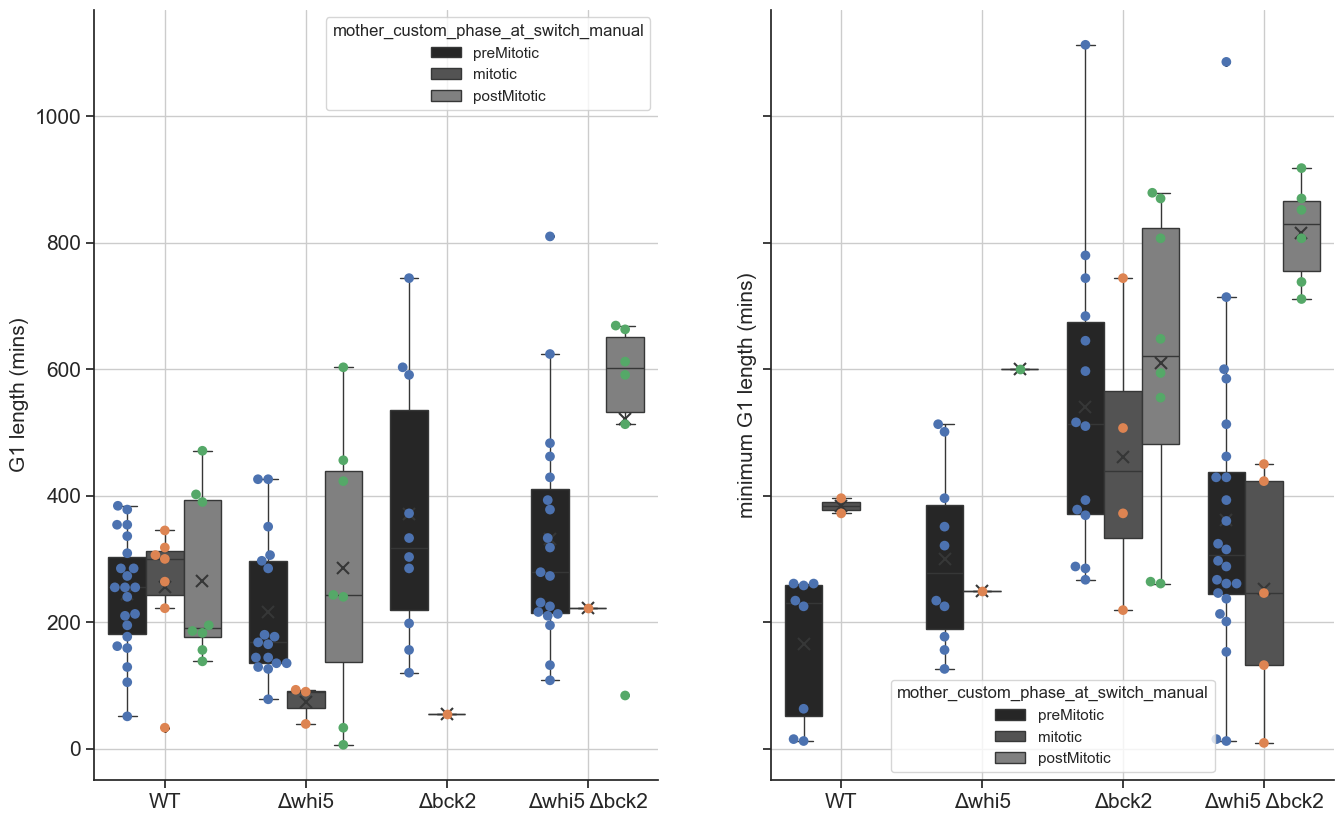

In [16]:
# plot it 
%matplotlib inline
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
plt.rcParams['ytick.labelsize'] = 15
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"},
    'flierprops':{'marker':'D', 'markerfacecolor':'black', 'markeredgecolor':'black', 'markersize':4}
}
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", 
       "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}

d, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharex= False, sharey= True, figsize=(16, 10))
d = sns.boxplot(data=plotting_df_complete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                # kind = "box",
                #height = 8,
                #aspect = 1,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                color = "grey",
                ax=ax1,
                **PROPS
               )
d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)

sns.despine(ax=ax1)
#plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
sns.swarmplot(data=plotting_df_complete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
              dodge = True,
              s =7,
              #color = "k",
              legend = False,
              ax=ax1
             )

plt.xlabel("", fontsize = 15)
plt.ylabel("G1 length (mins)", fontsize = 15)

d = sns.boxplot(data=plotting_df_incomplete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                # kind = "box",
                #height = 8,
                #aspect = 1,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                color = "grey",
                ax=ax2,
                **PROPS
               )
d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)
#ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 15)
sns.despine(ax=ax2)
#plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
sns.swarmplot(data=plotting_df_incomplete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
              dodge = True,
              s =7,
              #color = "k",
              legend = False,
              ax=ax2
             )



ax1.set_xlabel("", fontsize = 15)
ax2.set_xlabel("", fontsize = 15)
#ax3.xlabel("", fontsize = 15)
ax1.set_ylabel("G1 length (mins)", fontsize = 15)
ax2.set_ylabel("minimum G1 length (mins)", fontsize = 15)
#ax3.ylabel("", fontsize = 15)
ax1.grid()
ax2.grid()

#ax3.grid()
# plt.suptitle("First daughters of S/G2/M switchers", fontsize = 15, y =0.93)
#d.suptitle('First daughters of S/G2/M switchers')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel5_updated.svg", bbox_inches = 'tight')


# ***Fig6D and 6E: for only complete first daughters of S/G2/M switchers, plotting manual mother's combined_custom_S_stage_manual at switch*** 

C:\Users\timon\AppData\Local\Temp\ipykernel_21280\3732963475.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick_labels, fontsize=15)
C:\Users\timon\AppData\Local\Temp\ipykernel_21280\3732963475.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xtick_labels, fontsize=15)


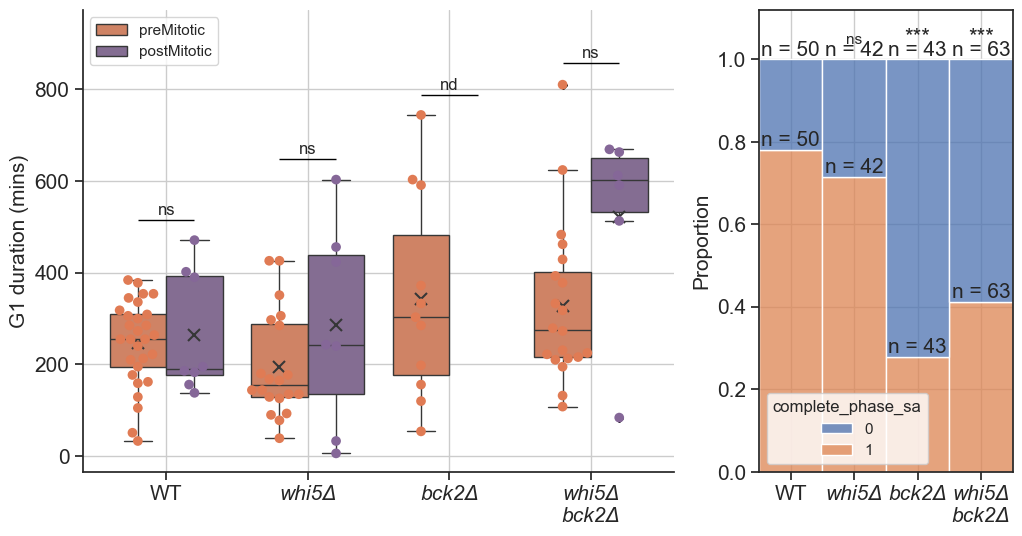

In [ ]:

import importlib
import sys
sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
import core
importlib.reload(core)
from core import annotate_mwu
from scipy.stats import chi2_contingency

%matplotlib inline
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
plt.rcParams['ytick.labelsize'] = 15
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"},
    'flierprops':{'marker':'D', 'markerfacecolor':'black', 'markeredgecolor':'black', 'markersize':4}
}
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}
phase_palette = {'preMitotic': '#e07b54', 'postMitotic': '#856798'}

# plotting_df_complete_chosen_strains = plotting_df_complete[(plotting_df_complete['strain_sa'] == "YCY024_1_WTlabelled")| (plotting_df_complete['strain_sa'] == "YCY038_1_Whi5Bck2doubledel_labelled")]
# display(plotting_df_complete_chosen_strains.strain_sa.unique())

# combine preanaphasic (premitotic) and anaphasic (mitotic) into one category 
plotting_df_complete.loc[plotting_df_complete['mother_custom_phase_at_switch_manual'] == "mitotic", 'mother_custom_phase_at_switch_manual'] = "preMitotic"
plotting_df_incomplete.loc[plotting_df_incomplete['mother_custom_phase_at_switch_manual'] == "mitotic", 'mother_custom_phase_at_switch_manual'] = "preMitotic"

xtick_labels = ["WT", "whi5Δ", "bck2Δ", "whi5Δ\nbck2Δ"]

#plot
d, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharex= False, sharey= False, figsize=(12, 6), gridspec_kw={'width_ratios': [0.7,0.3]})
d = sns.boxplot(data=plotting_df_complete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                palette=phase_palette,
                ax=ax1,
                **PROPS
               )
ax1.set_xticklabels(xtick_labels, fontsize=15)
for i, tick in enumerate(ax1.get_xticklabels()):
    if i > 0:
        tick.set_fontstyle("italic")

sns.despine(ax=ax1)

sns.swarmplot(data=plotting_df_complete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'postMitotic'],
              palette=phase_palette,
              dodge = True,
              s =7,
              legend = False,
              ax=ax1
             )

#combine complete and incomplete daughters plotting df
plotting_df_combined = pd.concat([plotting_df_complete, plotting_df_incomplete]).reset_index(drop = True)

# display(plotting_df_combined[['frame_i', 'Cell_ID', 'cell_saw_switch_sa', 'cell_saw_switch_as_bud_sa', 'S_switch_cells_daughter_wave_sa', 'Position_n', 'phase_length_sa', 'is_cell_dead_sa', 'does_cell_die_in_this_phase_sa', 'rep', 'relative_ID', 'cell_cycle_stage_sa',  'complete_phase_sa', 'cycle_saw_switch_sa', 'custom_S_stage', 'custom_postmitotic_stage', 'generation_num', 'relationship', 'complete_phase_sa', 'cycle_saw_switch_sa','mother_custom_phase_at_switch_manual']])
a = sns.histplot(data = plotting_df_combined,
                 hue = "complete_phase_sa",
                 x = "strain_sa", 
                 multiple = "fill", 
                 discrete = True,
                 ax =ax2,
                )
ax2.set_xticklabels(xtick_labels, fontsize=15)
for i, tick in enumerate(ax2.get_xticklabels()):
    if i > 0:
        tick.set_fontstyle("italic")
#https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
for container in ax2.containers:
    ax2.bar_label(container, labels = ["n = 50", "n = 42", "n = 43", "n = 63"], fontsize = 15)

ax1.legend(loc = 'upper left')
ax1.set_xlabel("", fontsize = 15)
ax2.set_xlabel("", fontsize = 15)
ax1.set_ylabel("G1 duration (mins)", fontsize = 15)
ax2.set_ylabel("Proportion", fontsize = 15)
ax1.grid()
ax2.grid()

# Chi-square significance tests on proportions barplot (each strain vs WT)
strain_order_6d = [
    'YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled',
    'YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'
]

def _p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

ref = strain_order_6d[0]
wt_counts = plotting_df_combined[plotting_df_combined['strain_sa'] == ref]['complete_phase_sa'].value_counts()
wt_complete   = wt_counts.get(1, wt_counts.get(True, 0))
wt_incomplete = wt_counts.get(0, wt_counts.get(False, 0))

ax2.set_ylim(0, 1.12)
for i, strain in enumerate(strain_order_6d[1:], start=1):
    s_counts = plotting_df_combined[plotting_df_combined['strain_sa'] == strain]['complete_phase_sa'].value_counts()
    s_complete   = s_counts.get(1, s_counts.get(True, 0))
    s_incomplete = s_counts.get(0, s_counts.get(False, 0))
    _, p, _, _ = chi2_contingency([[wt_complete, wt_incomplete], [s_complete, s_incomplete]])
    label = _p_to_stars(p)
    fs = 16 if label != "ns" else 11
    ax2.text(i, 1.03, label, ha='center', va='bottom', fontsize=fs)

core.annotate_significance_hue_vs_ref(
    ax=ax1,
    df=plotting_df_complete,
    x_col="strain_sa",
    y_col="G1_length_mins",
    hue_col="mother_custom_phase_at_switch_manual",
    x_order=strain_order_6d,
    hue_order=["preMitotic", "postMitotic"],
    ref_hue="preMitotic",
    test="mwu",
    min_n=5,
    show_n=False,
    text_gap=0.005,
    star_gap=-0.015,
)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\newpanels_DandE_01102024.svg", bbox_inches = 'tight')
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\Fig6_newpanels_DandE_01102024.svg", bbox_inches = 'tight')

In [27]:
# get statistics comparing pre- vs post-mitotic mothers within each strain for Fig 6D
import importlib
import sys

sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
import core
importlib.reload(core)
from core import run_stats

figure6d_strain_labels = {
    "YCY024_1_WTlabelled": "WT",
    "YCY030_2_Whi5del_labelled": "dwhi5",
    "YCY037_1_Bck2del_labelled": "dbck2",
    "YCY038_1_Whi5Bck2doubledel_labelled": "dwhi5_dbck2",
}

phase_labels = {
    "preMitotic": "preMitotic",
    "postMitotic": "postMitotic",
}

for strain, strain_label in figure6d_strain_labels.items():
    strain_df = plotting_df_complete[plotting_df_complete["strain_sa"] == strain].copy()
    run_stats(
        strain_df,
        [
            "G1_length_mins",
        ],
        comparisons=[
            ("preMitotic", "postMitotic"),
        ],
        group_labels=phase_labels,
        title = f"{strain_label} pre- vs post-mitotic",
        group_col="mother_custom_phase_at_switch_manual",
    )



WT pre- vs post-mitotic
Group: 'mother_custom_phase_at_switch_manual'  |  Value: 'G1_length_mins'


,mother_custom_phase_at_switch_manual,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,preMitotic,29,246.6,255.0,-0.62,0,Shapiro-Wilk,0.2703,True
1,postMitotic,8,265.1,190.5,0.56,0,Shapiro-Wilk,0.0404,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,preMitotic vs postMitotic,29,8,0.7192,0.6516,1.0,False,False,False



dwhi5 pre- vs post-mitotic
Group: 'mother_custom_phase_at_switch_manual'  |  Value: 'G1_length_mins'


,mother_custom_phase_at_switch_manual,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,preMitotic,20,194.7,154.5,0.84,0,Shapiro-Wilk,0.0190,False
1,postMitotic,7,286.3,243.0,0.01,0,Shapiro-Wilk,0.6331,True


...

    Not enough data points for comparison 'preMitotic' vs 'postMitotic', skipping.


""



dwhi5_dbck2 pre- vs post-mitotic
Group: 'mother_custom_phase_at_switch_manual'  |  Value: 'G1_length_mins'


,mother_custom_phase_at_switch_manual,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,preMitotic,20,326.7,276.0,1.27,1,Shapiro-Wilk,0.0223,False
1,postMitotic,6,522.0,601.5,-1.54,1,Shapiro-Wilk,0.0092,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,preMitotic vs postMitotic,20,6,0.0882,0.0312,0.0536,False,True,False


In [28]:
#colors and axis labels were edited in inkscape


#by changing multiple to 'dodge' in stacked histplot above and printing container labels, i got the following cell numbers for complete + incomplete cells
# WT 50 (39 complete + 11 incomplete)
# Whi5del 42 (30 complete + 12 incomplete)
# Bck2del 43 (12 complete + 31 incomplete)
# whi5bck2dd 63 (26 complete + 37 incomplete)



# ***Thesis_Fig: Whi5 dilution - Dataprep*** 

In [29]:
pre_switch_WT_G1s = overall_df[(overall_df['strain_sa'] == 'YCY024_1_WTlabelled') 
                            & (overall_df['growthmedium_sa'] == "SCD")
                            & (overall_df['daughterhood_binary_sa'] == 1)
                            & (overall_df['phase_saw_switch_sa'] == False)
                            & (overall_df['cell_cycle_stage_sa'] == "G1")
                            & (overall_df['complete_phase_sa'] == True)
                            & (overall_df['relationship_sa'] != "bud")]
#display(pre_switch_WT_G1s.columns.tolist())

In [30]:
pre_switch_WT_G1s['birthnorm_mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'] = np.nan
list_for_joining = []
for phase in pre_switch_WT_G1s['f_pos_cell_id_sa'].unique():
    phase_df= pre_switch_WT_G1s[pre_switch_WT_G1s['f_pos_cell_id_sa'] == phase]
    if ((phase_df['division_frame_i'].iloc[0]) >= 0):
        phase_df.sort_values(by=['frame_i'], inplace = True)
        for row in phase_df.index:
            phase_df['birthnorm_mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'].loc[row] = (
                (phase_df['mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'].loc[row])/(phase_df['mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'].iloc[0]))                                                                                                        
    list_for_joining.append(phase_df)
pre_switch_WT_G1s = pd.concat(list_for_joining).reset_index(drop = True)  

C:\Users\timon\AppData\Local\Temp\ipykernel_10692\2130348267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_switch_WT_G1s['birthnorm_mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'] = np.nan
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\2130348267.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phase_df.sort_values(by=['frame_i'], inplace = True)
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\2130348267.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documenta

In [31]:
# display(pre_switch_WT_G1s[['f_pos_cell_id_sa', 'frame_i', 'division_frame_i',  'mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell','birthnorm_mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell' ]].head(50))

# ***Thesis_Fig: Whi5 dilution - plot*** 

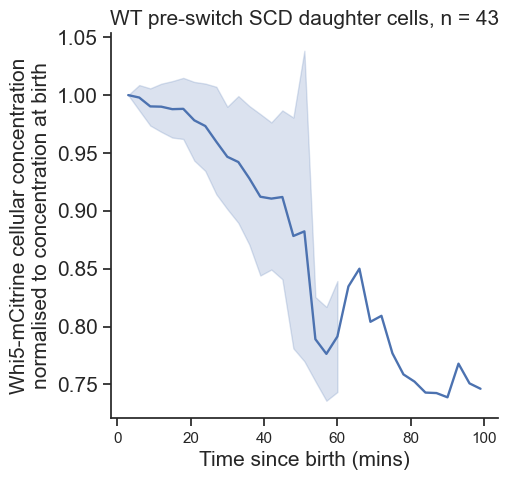

43

In [32]:
plt.figure(figsize=(5,5))
a = sns.lineplot(
    data = pre_switch_WT_G1s,
    x= 'time_in_cell_cycle_mins_sa',
    y='birthnorm_mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell'
)
a.set_title("WT pre-switch SCD daughter cells, n = 43", fontsize= 15)
a.set_ylabel("Whi5-mCitrine cellular concentration\nnormalised to concentration at birth", fontsize= 15)
a.set_xlabel("Time since birth (mins)", fontsize= 15)
sns.despine(ax = a)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Thesis figures\Whi_dilution_panel.svg", bbox_inches = 'tight')
plt.show()
display(len(pre_switch_WT_G1s.f_pos_cell_id_sa.unique()))



# ***Thesis_Fig: Whi5 nuclear re-entry after switch in G1 switchers - Dataprep*** 

In [33]:
# get subset

complete_cycles = overall_df[(overall_df['cycle_saw_switch_sa'] == True)
                    & (overall_df['cell_saw_switch_in_G1_sa'] == True)
                    & (overall_df['complete_cycle_sa'] == True)
                    & (overall_df['relationship_sa'] != "bud")]
#display(complete_cycles.columns.tolist())

In [34]:
# calculating time relative to switch and scaling whi5 nuclear mean pixel intensity from 0 to 1

import warnings
new = []
complete_cycles['time_rel_switch_frames'] = np.nan
complete_cycles['time_rel_switch_frames_norm'] = np.nan
complete_cycles['scaled_nuclear_whi5'] = np.nan

with warnings.catch_warnings(record=True):
    for cycle in complete_cycles['f_pos_cell_id_sa'].unique():
        cycle_df = complete_cycles[complete_cycles['f_pos_cell_id_sa'] == cycle]
        cycle_df['time_rel_switch_frames'] = (cycle_df['frame_i'])- 50
        cycle_df.sort_values(by=['frame_i'], inplace = True)
        cycle_start_frame_rel_switch = cycle_df['time_rel_switch_frames'].iloc[0]
        cycle_end_frame_rel_switch = cycle_df['time_rel_switch_frames'].iloc[-1]
        for row in cycle_df.index:
            if cycle_df.loc[row, 'frame_i'] <50 :
                cycle_df['time_rel_switch_frames_norm'].loc[row] = (-(cycle_df['time_rel_switch_frames'].loc[row])/cycle_start_frame_rel_switch)
            else:
                cycle_df['time_rel_switch_frames_norm'].loc[row] = ((cycle_df['time_rel_switch_frames'].loc[row])/cycle_end_frame_rel_switch)
        
        max_whi5 = cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].max()
        min_whi5 = cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].min()
        for row in cycle_df.index:
            cycle_df['scaled_nuclear_whi5'].loc[row] = (((cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].loc[row]) - min_whi5)/(max_whi5 - min_whi5))
        new.append(cycle_df)
plotting_df = pd.concat(new).reset_index(drop = True)
display(plotting_df.head(10))

C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_cycles['time_rel_switch_frames'] = np.nan
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_cycles['time_rel_switch_frames_norm'] = np.nan
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,frame_i,Cell_ID,cell_cycle_stage_sa,cell_vol_fl_sa,cell_vol_vox_sa,division_frame_i_sa,emerg_frame_i_sa,...,custom_G1_stage_manual,preStart_G1_duration_frames_manual,postStart_G1_duration_frames_manual,total_G1_len_mins,frame_rel_to_bud_emergence,bud_emerg_frame,time_rel_to_bud_emergence_mins,time_rel_switch_frames,time_rel_switch_frames_norm,scaled_nuclear_whi5
0,41,41,41,41,1,G1,73.184979,112685.562500,41.0,-1.0,...,NaN,NaN,NaN,NaN,-58.0,99.0,-174.0,-9,-1.000000,0.117712
1,42,42,42,42,1,G1,74.699418,115017.398438,41.0,-1.0,...,NaN,NaN,NaN,NaN,-57.0,99.0,-171.0,-8,-0.888889,0.103870
2,43,43,43,43,1,G1,74.856085,115258.625000,41.0,-1.0,...,NaN,NaN,NaN,NaN,-56.0,99.0,-168.0,-7,-0.777778,0.121143
3,44,44,44,44,1,G1,74.357928,114491.593750,41.0,-1.0,...,NaN,NaN,NaN,NaN,-55.0,99.0,-165.0,-6,-0.666667,0.000000
4,45,45,45,45,1,G1,75.707063,116568.906250,41.0,-1.0,...,NaN,NaN,NaN,NaN,-54.0,99.0,-162.0,-5,-0.555556,0.022634
5,46,46,46,46,1,G1,76.644810,118012.789062,41.0,-1.0,...,NaN,NaN,NaN,NaN,-53.0,99.0,-159.0,-4,-0.444444,0.123389
6,47,47,47,47,1,G1,76.324833,117520.109375,41.0,-1.0,...,NaN,NaN,NaN,NaN,-52.0,99.0,-156.0,-3,-0.333333,0.107596
7,48,48,48,48,1,G1,78.038530,120158.750000,41.0,-1.0,...,NaN,NaN,NaN,NaN,-51.0,99.0,-153.0,-2,-0.222222,0.184414
8,49,49,49,49,1,G1,74.546657,114782.187500,41.0,-1.0,...,NaN,NaN,NaN,NaN,-50.0,99.0,-150.0,-1,-0.111111,0.242543
9,50,50,50,50,1,G1,77.682797,119611.015625,41.0,-1.0,...,NaN,NaN,NaN,NaN,-49.0,99.0,-147.0,0,0.000000,0.258150


# ***Thesis_Fig: Whi5 nuclear re-entry after switch in G1 switchers - Plot*** 

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

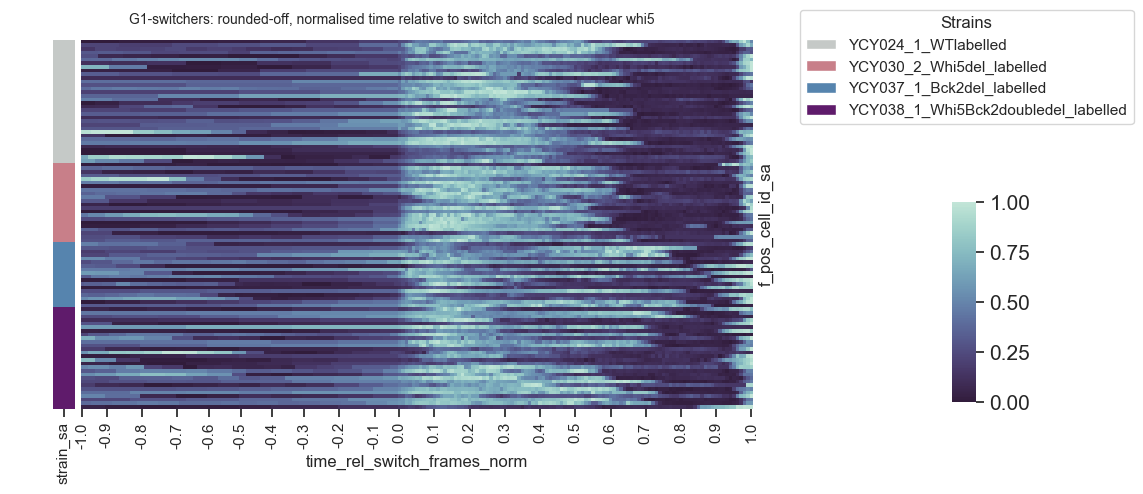

In [35]:
# heatmap with rounded-off, normalised time relative to switch and scaled nuclear whi5 and strain color patches

lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#5f1b6b"}

plotting_df['time_rel_switch_frames_norm'] = plotting_df['time_rel_switch_frames_norm'].round(2)
heatmap_df = plotting_df.pivot_table(index = ["f_pos_cell_id_sa", "strain_sa"],
                               values = "scaled_nuclear_whi5",
                               columns = "time_rel_switch_frames_norm")
heatmap_df.ffill(axis=1, inplace = True) 
heatmap_df.reset_index(level = ("strain_sa", ), inplace = True)
row_colors = heatmap_df['strain_sa'].map(lut)
sns.light_palette("seagreen", as_cmap=True)
g = sns.clustermap(data=heatmap_df.drop(['strain_sa'], axis=1), 
                   figsize=(8,5),
                   row_colors=row_colors, 
                   cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True, reverse = True),
                   row_cluster=False, 
                   col_cluster=False, 
                   dendrogram_ratio=0.05, 
                   cbar_pos=(1.2, .2, .03, .4),
                   yticklabels = False,
                   xticklabels = 1)
# ax_row_colors = g.ax_row_colors
# box = ax_row_colors.get_position()
# box_heatmap = g.ax_heatmap.get_position()
# ax_row_colors.set_position([box_heatmap.max[0], box.y0, box.width*1.5, box.height])

from matplotlib.patches import Patch

handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Strains',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')

g.fig.suptitle('G1-switchers: rounded-off, normalised time relative to switch and scaled nuclear whi5', fontsize =10) 
#display(g.ax_heatmap.get_xticklabels())
#only custom xtick labels to be printed
xticks_to_keep = [0, 7, 17, 27, 36, 45, 54, 63, 73, 83,  90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190]
[a.set_visible(False) for (i,a) in enumerate(g.ax_heatmap.get_xticklabels()) if i not in xticks_to_keep]
[a.set_visible(False) for (i,a) in enumerate(g.ax_heatmap.xaxis.get_major_ticks()) if i not in xticks_to_keep]


#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Thesis figures\whi5_reentry_g1switchers.svg", bbox_inches = 'tight')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Thesis figures\whi5_reentry_g1switchers.png", bbox_inches = 'tight')
#plt.xlabel("Time relative to switch - normalised")
#plt.ylabel("")

# ***Thesis_Fig: Whi5 nuclear re-entry after switch in S/G2/M switchers - Dataprep*** 

In [36]:
# get subset

complete_cycles = overall_df[(overall_df['cycle_saw_switch_sa'] == True)
                    & (overall_df['cell_saw_switch_in_S_sa'] == True)
                    & (overall_df['complete_cycle_sa'] == True)
                    & (overall_df['relationship_sa'] != "bud")]

In [37]:
# calculating time relative to switch and scaling whi5 nuclear mean pixel intensity from 0 to 1

import warnings
new = []
complete_cycles['time_rel_switch_frames'] = np.nan
complete_cycles['time_rel_switch_frames_norm'] = np.nan
complete_cycles['scaled_nuclear_whi5'] = np.nan

with warnings.catch_warnings(record=True):
    for cycle in complete_cycles['f_pos_cell_id_sa'].unique():
        cycle_df = complete_cycles[complete_cycles['f_pos_cell_id_sa'] == cycle]
        cycle_df['time_rel_switch_frames'] = (cycle_df['frame_i'])- 50
        cycle_df.sort_values(by=['frame_i'], inplace = True)
        cycle_start_frame_rel_switch = cycle_df['time_rel_switch_frames'].iloc[0]
        cycle_end_frame_rel_switch = cycle_df['time_rel_switch_frames'].iloc[-1]
        for row in cycle_df.index:
            if cycle_df.loc[row, 'frame_i'] <50 :
                cycle_df['time_rel_switch_frames_norm'].loc[row] = (-(cycle_df['time_rel_switch_frames'].loc[row])/cycle_start_frame_rel_switch)
            else:
                cycle_df['time_rel_switch_frames_norm'].loc[row] = ((cycle_df['time_rel_switch_frames'].loc[row])/cycle_end_frame_rel_switch)
        
        max_whi5 = cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].max()
        min_whi5 = cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].min()
        for row in cycle_df.index:
            cycle_df['scaled_nuclear_whi5'].loc[row] = (((cycle_df['mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted'].loc[row]) - min_whi5)/(max_whi5 - min_whi5))
        new.append(cycle_df)
plotting_df = pd.concat(new).reset_index(drop = True)
display(plotting_df.head(10))

C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_cycles['time_rel_switch_frames'] = np.nan
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_cycles['time_rel_switch_frames_norm'] = np.nan
C:\Users\timon\AppData\Local\Temp\ipykernel_10692\725195078.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,frame_i,Cell_ID,cell_cycle_stage_sa,cell_vol_fl_sa,cell_vol_vox_sa,division_frame_i_sa,emerg_frame_i_sa,...,custom_G1_stage_manual,preStart_G1_duration_frames_manual,postStart_G1_duration_frames_manual,total_G1_len_mins,frame_rel_to_bud_emergence,bud_emerg_frame,time_rel_to_bud_emergence_mins,time_rel_switch_frames,time_rel_switch_frames_norm,scaled_nuclear_whi5
0,381,381,381,31,2,G1,122.752256,189006.093750,31.0,-1.0,...,NaN,NaN,NaN,NaN,-2.0,33.0,-6.0,-19,-1.000000,0.056004
1,382,382,382,32,2,G1,125.106302,192630.703125,31.0,-1.0,...,NaN,NaN,NaN,NaN,-1.0,33.0,-3.0,-18,-0.947368,0.046719
2,383,383,383,33,2,S,123.720228,190496.515625,31.0,-1.0,...,NaN,NaN,NaN,NaN,0.0,33.0,0.0,-17,-0.894737,0.044869
3,384,384,384,34,2,S,122.926718,189274.718750,31.0,-1.0,...,NaN,NaN,NaN,NaN,1.0,33.0,3.0,-16,-0.842105,0.009880
4,385,385,385,35,2,S,111.780937,172113.156250,31.0,-1.0,...,NaN,NaN,NaN,NaN,2.0,33.0,6.0,-15,-0.789474,0.010730
5,386,386,386,36,2,S,119.864566,184559.812500,31.0,-1.0,...,NaN,NaN,NaN,NaN,3.0,33.0,9.0,-14,-0.736842,0.021718
6,387,387,387,37,2,S,118.654273,182696.281250,31.0,-1.0,...,NaN,NaN,NaN,NaN,4.0,33.0,12.0,-13,-0.684211,0.008940
7,388,388,388,38,2,S,117.830228,181427.468750,31.0,-1.0,...,NaN,NaN,NaN,NaN,5.0,33.0,15.0,-12,-0.631579,0.000000
8,389,389,389,39,2,S,119.058644,183318.906250,31.0,-1.0,...,NaN,NaN,NaN,NaN,6.0,33.0,18.0,-11,-0.578947,0.042422
9,390,390,390,40,2,S,118.244950,182066.031250,31.0,-1.0,...,NaN,NaN,NaN,NaN,7.0,33.0,21.0,-10,-0.526316,0.017408


# ***Thesis_Fig: Whi5 nuclear re-entry after switch in S/G2/M switchers - Plot*** 

Text(0.5, 0.98, 'S/G2/M-switchers: rounded-off, normalised time relative to switch and scaled nuclear whi5')

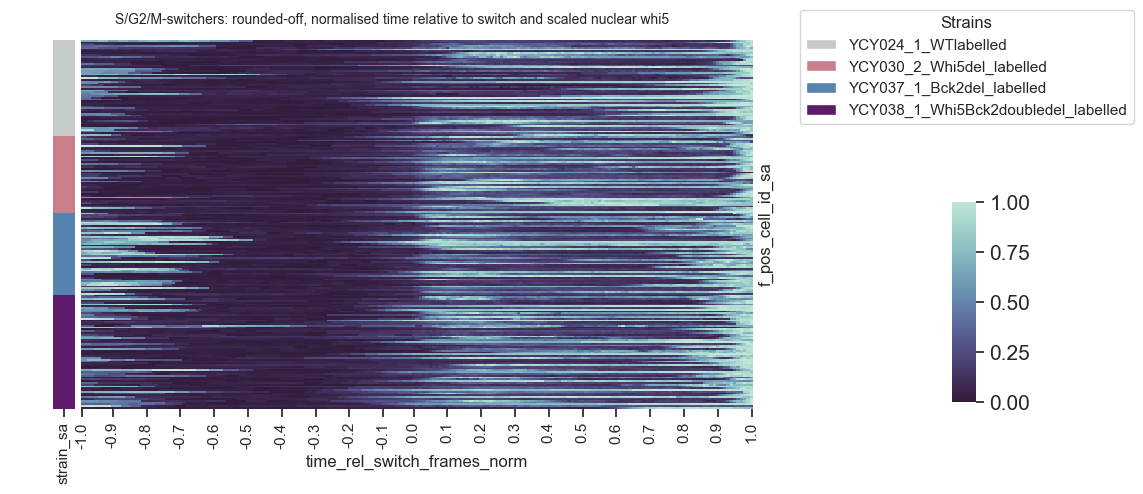

In [38]:
# heatmap with rounded-off, normalised time relative to switch and scaled nuclear whi5 and strain color patches

lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#5f1b6b"}

plotting_df['time_rel_switch_frames_norm'] = plotting_df['time_rel_switch_frames_norm'].round(2)
heatmap_df = plotting_df.pivot_table(index = ["f_pos_cell_id_sa", "strain_sa"],
                               values = "scaled_nuclear_whi5",
                               columns = "time_rel_switch_frames_norm")
heatmap_df.ffill(axis=1, inplace = True) 
heatmap_df.reset_index(level = ("strain_sa", ), inplace = True)
row_colors = heatmap_df['strain_sa'].map(lut)
sns.light_palette("seagreen", as_cmap=True)
g = sns.clustermap(data=heatmap_df.drop(['strain_sa'], axis=1), 
                   figsize=(8,5),
                   row_colors=row_colors, 
                   cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True, reverse = True),
                   row_cluster=False, 
                   col_cluster=False, 
                   dendrogram_ratio=0.05, 
                   cbar_pos=(1.2, .2, .03, .4),
                   yticklabels = False,
                   xticklabels = 1)
# ax_row_colors = g.ax_row_colors
# box = ax_row_colors.get_position()
# box_heatmap = g.ax_heatmap.get_position()
# ax_row_colors.set_position([box_heatmap.max[0], box.y0, box.width*1.5, box.height])

from matplotlib.patches import Patch

handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Strains',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')
#display(g.ax_heatmap.get_xticklabels())
#only custom xtick labels to be printed
xticks_to_keep = [0, 9, 19, 29, 39, 49, 59, 69, 79, 89,  98, 108, 118, 128, 138, 148, 158, 168, 178, 188, 198]
[a.set_visible(False) for (i,a) in enumerate(g.ax_heatmap.get_xticklabels()) if i not in xticks_to_keep]
[a.set_visible(False) for (i,a) in enumerate(g.ax_heatmap.xaxis.get_major_ticks()) if i not in xticks_to_keep]

g.fig.suptitle('S/G2/M-switchers: rounded-off, normalised time relative to switch and scaled nuclear whi5', fontsize =10) 
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Thesis figures\whi5_reentry_Sswitchers.svg", bbox_inches = 'tight')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Thesis figures\whi5_reentry_Sswitchers.png", bbox_inches = 'tight')
#plt.xlabel("Time relative to switch - normalised")
#plt.ylabel("")